In [1]:
from src import *
import matplotlib.pyplot as plt

logger = logging.getLogger("global_logger")
logging.basicConfig(filename='gap_analysis.log',format='%(levelname)s: %(message)s', encoding='utf-8', filemode='w', level=logging.DEBUG)
logger.info("NEW START")

action_names = ["kick", "sidestep", "turn", "walk"]


replay_settings = SimulationParameters("default")
simulator = Simulator()
gap_objects = simulator.simulation_gap(settings=replay_settings, replay_mode=ExperimentMode.DEL_EXISTING, extraction_mode=ExperimentMode.DEL_EXISTING)
sorted_gos = [[go for go in gap_objects if go.action_name is action_name] for action_name in action_names]

hinges = ["lShoulderPitch", "rShoulderPitch"]
hinge = "lShoulderPitch"
def print_all():
    for go_list in sorted_gos:
        for go in go_list:
            go.load()
            p_gap = go.get_total_gap([hinge])
            x = range(0, len(p_gap[hinge]))
            plt.plot(x, p_gap[hinge])
            go.unload()
        plt.show()

print(gap_objects)




[<src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD671FD0>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD661450>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD661590>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD63A060>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD63A8B0>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD54F9B0>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD6138A0>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD613680>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBCC73550>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBCC73450>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD3123F0>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000021BBD313200>, <src.Utils.SimulationGapData.SimulationGapData object at 0x0000

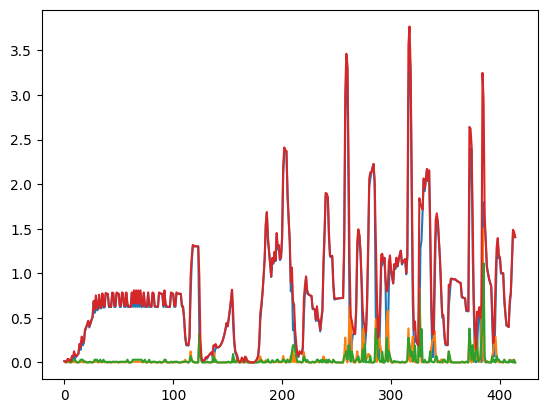

In [3]:
test = sorted_gos[1][1]
test.load()
p_gap = test.get_pos_gap([hinge])
v_gap = test.get_vel_gap([hinge])
a_gap = test.get_acc_gap([hinge])
total_gap = test.get_total_gap([hinge])
x = range(0, len(p_gap[hinge]))
plt.plot(x, p_gap[hinge])
plt.plot(x[1:], v_gap[hinge])
plt.plot(x[2:], a_gap[hinge])
plt.plot(x, total_gap[hinge])
plt.show()
test.unload()